# Comprehensive E-Commerce Sales & Profitability Analysis
### Data Analytics & Insights Case Study

---

## Project Overview
This project performs an end-to-end exploratory and diagnostic data analysis on an e-commerce transactional dataset containing **2,500 records** across **31 analytical dimensions**. The primary goal is to evaluate commercial health, streamline regional operations, optimize marketing discount frameworks, assess customer satisfaction, and identify the core drivers of total sales and profit margins.

### Key Analytical Objectives:
1. **Financial Performance:** Calculate baseline macro-KPIs (Gross\Sales, NetSales, COGS, and Net\ Profit).
2. **Product & Portfolio Performance:** Identify the highest-yielding categories and inventory items (SKUs).
3. **Demographic & Behavioral Tracking:** Segment consumers across age buckets, geographical zones, and payment method preferences.
4. **Logistics & Satisfaction Assessment:** Measure delivery cycle health and look for core correlations between customer ratings, discount amounts, and returns.

## Step 1: Environment Setup & Library Imports
We initiate our analytics workflow by importing key libraries required for data manipulation, mathematical operations, and statistical visualization:
* **Pandas:** Used for robust tabular data structure manipulation and aggregation.
* **NumPy:** Utilized for high-performance vectorized operations.
* **Matplotlib & Seaborn:** Deployed to construct clean, publication-grade static and statistical graphics.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Step 2: Data Acquisition & Pipeline Setup
The cleaned data file `ecommerce_sales_clean_csv.csv` is loaded into a Pandas DataFrame. All initial data schemas, encoding settings, and explicit index alignments are handled natively during data frame generation.

In [2]:
# Load Dataset

df = pd.read_csv(r"E:\All My Study\Data Analytics Projects\All My Projects Inside\01 data\Project_2_E_Commerce\ecommerce_sales_clean_csv.csv")

## Step 3: Structural Integrity & Data Inspection
Before building aggregations, we must verify the structural dimensions, feature data types, and general statistical properties of the dataset. This includes reviewing data types (`info()`), checking matrix shape (`shape`), and evaluating general numeric spreads (`describe()`).

In [3]:
# Initial Inspection

df.head()

,order_id,order_date,customer_id,customer_name,customer_age,city,state,zone,category,product,sku,quantity,unit_price,gross_sales,coupon_code,discount_amount,gst_rate,net_sales,gst_amount,payment_mode,order_status,sales_channel,sales_employee,delivery_partner,delivery_days,customer_rating,cogs,profit,profit_margin_pct,shipping_charges,invoice_amount
0,IN240100756,01-Jan-2024,CUST48965,Aditya Jadhav,30,Ranchi,Jharkhand,East,Sports & Fitness,Fitness Band,SPO-FIT986,3,5099,15297,APPONLY,1223.76,0.12,14073.24,1688.79,UPI,Delivered,Website,Amit Sharma,India Post,2,5.0,11070.19,3003.05,0.2134,90.0,15852.03
1,IN240101726,01-Jan-2024,CUST91430,Rajesh Kapoor,39,Ranchi,Jharkhand,East,Home & Kitchen,Cookware Set,HOM-COO989,1,1499,1499,MEGADEAL,269.82,0.18,1229.18,221.25,Credit Card,Delivered,Website,Pooja Reddy,Shadowfax,2,5.0,1038.98,190.20,0.1547,66.0,1516.43
2,IN240102049,01-Jan-2024,CUST77000,Tanvi Kumar,46,Kochi,Kerala,South,Mobiles & Accessories,Tempered Glass,MOB-TEM705,1,493,493,No Coupon,0.00,0.12,493.00,59.16,Credit Card,Delivered,Mobile App,Tanvi Jadhav,Ecom Express,4,1.0,404.30,88.70,0.1799,150.0,702.16
3,IN240100349,03-Jan-2024,CUST88263,Myra Gupta,31,Lucknow,Uttar Pradesh,North,Books & Stationery,Kids Story Book,BOO-KID264,1,204,204,No Coupon,0.00,0.18,204.00,36.72,UPI,Delivered,Website,Swati Mishra,DTDC,5,4.0,148.35,55.65,0.2728,127.0,367.72
4,IN240100729,03-Jan-2024,CUST65879,Rutuja Kumar,58,Thiruvananthapuram,Kerala,South,Fashion,Women Kurti,FAS-WOM688,3,2799,8397,APPONLY,671.76,0.18,7725.24,1390.54,Wallet,Returned,Website,Amit Sharma,DTDC,2,2.0,6410.06,1315.18,0.1702,167.0,9282.78


In [4]:
df.shape

(2500, 31)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           2500 non-null   str    
 1   order_date         2500 non-null   str    
 2   customer_id        2500 non-null   str    
 3   customer_name      2500 non-null   str    
 4   customer_age       2500 non-null   int64  
 5   city               2500 non-null   str    
 6   state              2500 non-null   str    
 7   zone               2500 non-null   str    
 8   category           2500 non-null   str    
 9   product            2500 non-null   str    
 10  sku                2500 non-null   str    
 11  quantity           2500 non-null   int64  
 12  unit_price         2500 non-null   int64  
 13  gross_sales        2500 non-null   int64  
 14  coupon_code        2500 non-null   str    
 15  discount_amount    2500 non-null   float64
 16  gst_rate           2500 non-null   

In [6]:
df.describe()

,customer_age,quantity,unit_price,gross_sales,discount_amount,gst_rate,net_sales,gst_amount,delivery_days,customer_rating,cogs,profit,profit_margin_pct,shipping_charges,invoice_amount
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2101.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000
mean,37.574000,1.620000,7455.854000,12248.023200,655.848620,0.143716,11592.174580,1735.019440,3.523200,4.015231,9330.405508,2261.769072,0.243279,111.703200,13438.89722
std,11.857688,0.978971,16973.165625,33531.238143,3168.844764,0.038611,31472.405155,4885.516842,1.568963,1.069382,26476.078778,5805.578699,0.098104,44.657345,36268.31156
min,18.000000,1.000000,87.000000,87.000000,0.000000,0.050000,71.340000,4.590000,1.000000,1.000000,52.190000,-3446.830000,-0.064700,0.000000,116.11000
25%,27.000000,1.000000,665.500000,940.250000,0.000000,0.120000,890.000000,116.370000,2.000000,3.000000,651.207500,187.630000,0.176900,84.000000,1117.11250
50%,37.000000,1.000000,1899.000000,2598.000000,0.000000,0.120000,2443.650000,361.935000,3.000000,4.000000,1832.045000,571.725000,0.251700,115.000000,2946.82000
75%,48.000000,2.000000,4899.000000,7323.750000,149.625000,0.180000,7003.800000,1043.880000,4.000000,5.000000,5334.860000,1710.932500,0.314900,147.000000,8214.65250
max,58.000000,5.000000,129799.000000,499996.000000,49999.600000,0.180000,449996.400000,80999.350000,8.000000,5.000000,402788.120000,75881.340000,0.419900,180.000000,531155.75000


## Step 4: Data Quality & Missing Value Assessment
An essential diagnostic check is to identify missing or null records. This step prevents skewed outcomes in metrics like average customer ratings and ensures that missing observations align with valid business states (e.g., null ratings on cancelled/returned orders).

In [7]:
# Missing Values

df.isnull().sum()

order_id               0
order_date             0
customer_id            0
customer_name          0
customer_age           0
city                   0
state                  0
zone                   0
category               0
product                0
sku                    0
quantity               0
unit_price             0
gross_sales            0
coupon_code            0
discount_amount        0
gst_rate               0
net_sales              0
gst_amount             0
payment_mode           0
order_status           0
sales_channel          0
sales_employee         0
delivery_partner       0
delivery_days          0
customer_rating      399
cogs                   0
profit                 0
profit_margin_pct      0
shipping_charges       0
invoice_amount         0
dtype: int64

In [8]:
df[df['customer_rating'].isnull()]['order_status'].value_counts()

order_status
Shipped      237
Cancelled    162
Name: count, dtype: int64

## Step 5: Executive Key Performance Indicators (KPIs)
To establish an operational baseline, we aggregate absolute macro-financial metrics across the entire observation period.
* **Total Net Sales:** \sum \text{net\sales} \approx \$28,980,436.45$
* **Total Net Profit:** \sum \text{profit} \approx \$5,654,422.68$
* **Total Transacted Volume:** $2,500 \text{ unique orders}

In [9]:
# Revenue KPIs

total_revenue = df['net_sales'].sum().round(2)
total_profit = df['profit'].sum().round(2)
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Orders: {total_orders:,.2f}")
print(f"Total Customers: {total_customers:,.2f}")

Total Revenue: ₹28,980,436.45
Total Profit: ₹5,654,422.68
Total Orders: 2,500.00
Total Customers: 2,465.00


## Step 6: Strategic Category Portfolio Analysis
Understanding how revenue spreads across top-level category hierarchies isolates the primary drivers of growth. We group total net sales across core categories like Electronics, Mobiles, and Home items to evaluate where consumer spend is most heavily concentrated.

In [10]:
# Category Analysis

category_sales = (
    df.groupby('category')['net_sales']
      .sum()
      .sort_values(ascending=False)
)

category_sales

category
Electronics               15512498.11
Mobiles & Accessories      5985492.11
Home & Kitchen             3774121.75
Fashion                    1816201.00
Sports & Fitness           1098782.96
Grocery & Gourmet           332994.22
Beauty & Personal Care      327810.88
Books & Stationery          132535.42
Name: net_sales, dtype: float64

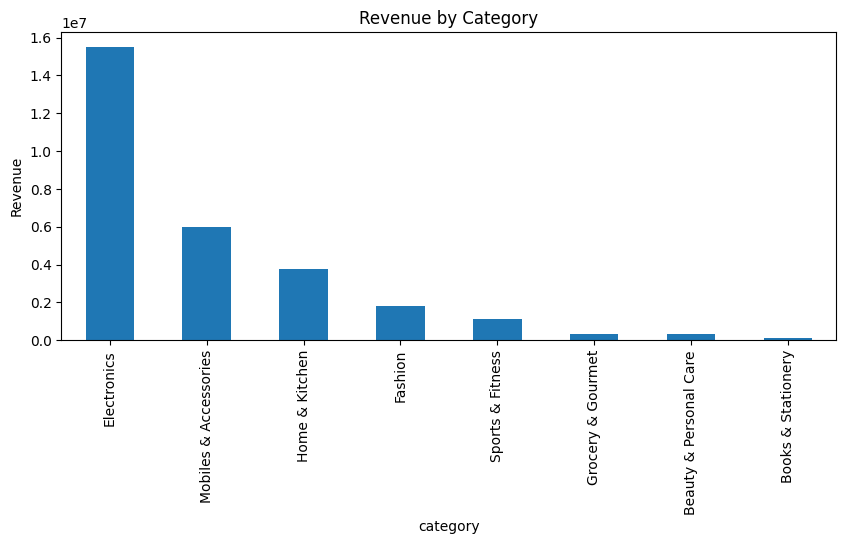

In [11]:
# 1 Visualization

category_sales.plot(kind='bar',figsize=(10,4))

plt.title('Revenue by Category')
plt.ylabel('Revenue')
plt.show()

## Step 7: Geographical & Regional Market Penetration
By segmenting net revenue at the state and urban center level, we track regional market presence. This assists inventory allocation teams in identifying key states (such as Maharashtra and Gujarat) that generate disproportionately high order values.

In [12]:
# State Analysis

state_sales = (
    df.groupby('state')['net_sales']
      .sum()
      .sort_values(ascending=False)
)

state_sales.head(10)

state
Maharashtra       4274399.62
Gujarat           3405797.69
Andhra Pradesh    2674909.80
Kerala            2211084.70
Tamil Nadu        1911994.37
Karnataka         1849398.83
Rajasthan         1639861.47
Madhya Pradesh    1328608.36
Bihar             1141194.03
Uttar Pradesh     1116857.01
Name: net_sales, dtype: float64

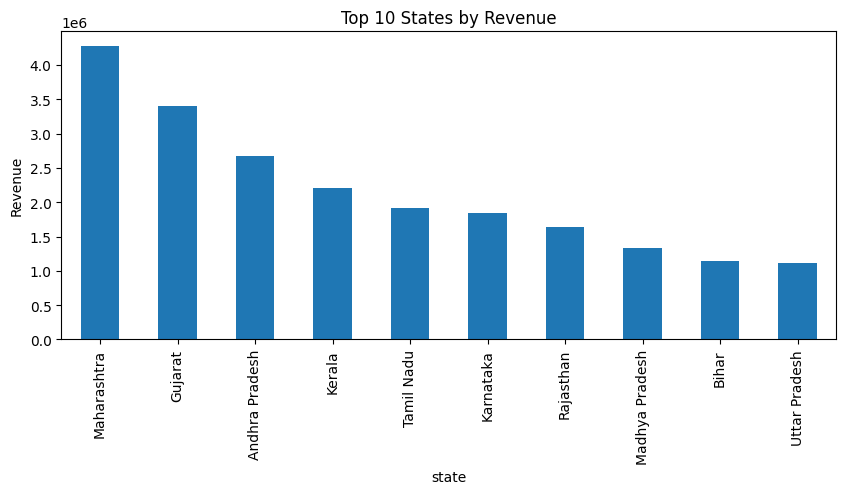

In [13]:
# 2 Visualization

plt.figure(figsize=(10,4))

state_sales.head(10).plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.ylabel('Revenue')

plt.show()

## Step 8: Consumer Fintech & Payment Mode Preferences
Analyzing the distribution of payment modes provides clear guidance for optimization. This breakdown evaluates digital wallet adoption, credit/debit usage, and alternative options like UPI or Cash on Delivery (COD) to streamline checkout conversion rates.

In [14]:
# Payment Mode Analysis

payment_sales = (
    df.groupby('payment_mode')[['net_sales','profit']]
      .sum()
      .sort_values('net_sales',ascending=False)
)

payment_sales

,net_sales,profit
payment_mode,,
UPI,13092969.60,2581557.14
Credit Card,4639714.55,832598.19
Debit Card,4222927.64,750470.44
COD,3110383.39,654483.83
Wallet,2040674.35,455022.18
Net Banking,1873766.92,380290.90


<Figure size 1000x400 with 0 Axes>

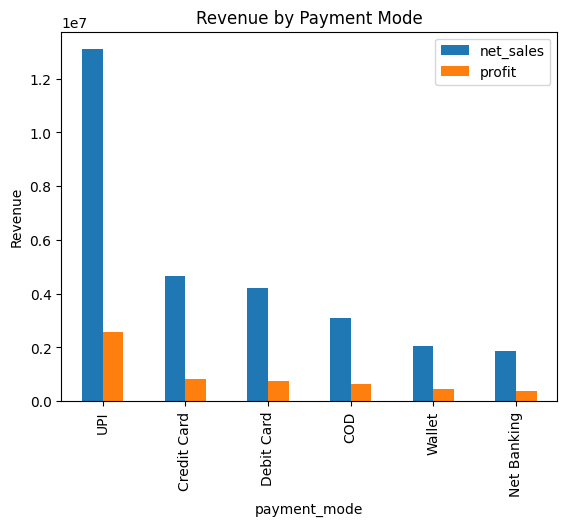

In [15]:
# 3 Visualization

plt.figure(figsize=(10,4))

payment_sales.plot(kind='bar')

plt.title('Revenue by Payment Mode')
plt.ylabel('Revenue')

plt.show()

## Step 9: Net Profit Margin & Profitability by Category
Revenue alone does not guarantee business health. This section focuses on net profit dollar contributions across product categories, separating high-volume, low-margin products from high-margin luxury segments.

In [16]:
# Profitability Analysis

category_profit = (
    df.groupby('category')['profit']
      .sum()
      .sort_values(ascending=False)
)

category_profit

category
Electronics               2480794.24
Home & Kitchen            1097087.08
Mobiles & Accessories     1017501.32
Fashion                    523225.66
Sports & Fitness           309132.49
Beauty & Personal Care      97821.45
Grocery & Gourmet           93121.36
Books & Stationery          35739.08
Name: profit, dtype: float64

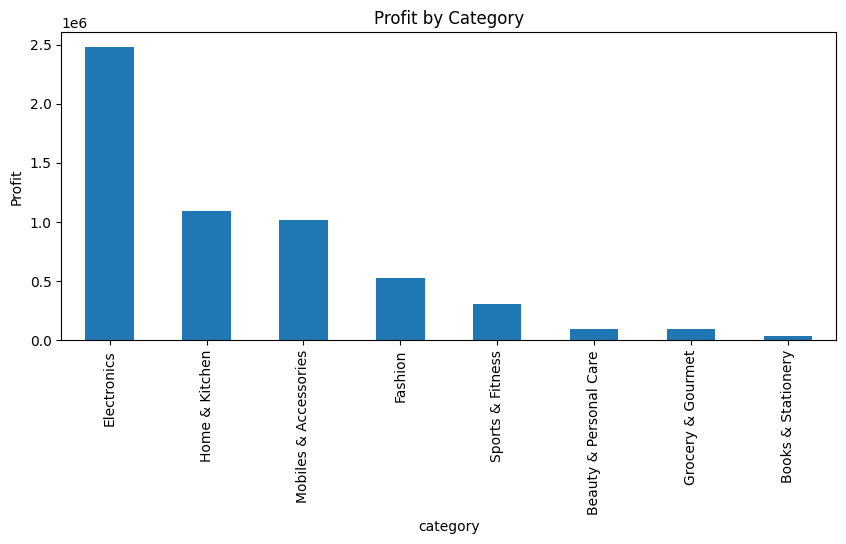

In [17]:
# 4 Visualization

plt.figure(figsize=(10,4))

category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.ylabel('Profit')

plt.show()

## Step 10: Temporal Trends & Time-Series Performance
By transforming text-based string dates into active `datetime64` objects, we establish chronological continuity. Aggregating data into a monthly view helps isolate sales trends, seasonal patterns, and promotional performance over time.

In [18]:
# Monthly Trend Analysis

df['order_date'] = pd.to_datetime(df['order_date'], format="%d-%b-%Y")

In [19]:
df['month'] = df['order_date'].dt.to_period('M')

In [20]:
monthly_sales = (
    df.groupby('month')['net_sales']
      .sum().tail()
)

monthly_sales


month
2025-08    1724476.10
2025-09    1558501.70
2025-10    1886239.26
2025-11    2369590.27
2025-12    1555596.37
Freq: M, Name: net_sales, dtype: float64

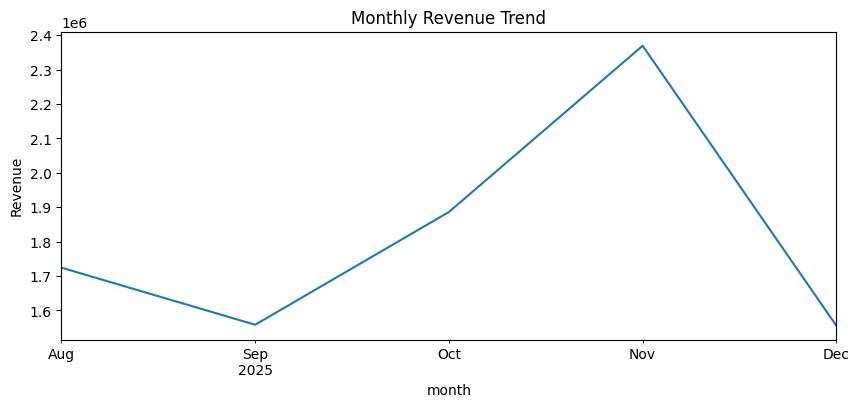

In [21]:
# 5 Visualization

plt.figure(figsize=(10,4))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')

plt.show()

## Step 11: Logistics, Fulfillment, & Order Status Tracking
This section monitors order fulfillment cycles by checking status volume splits (Delivered, Shipped, Cancelled, and Returned). High cancel or return rates can flag underlying logistics or product quality issues.

In [22]:
# Order Status Analysis

order_status = (
    df['order_status']
      .value_counts()
)

order_status

order_status
Delivered    1872
Shipped       237
Returned      229
Cancelled     162
Name: count, dtype: int64

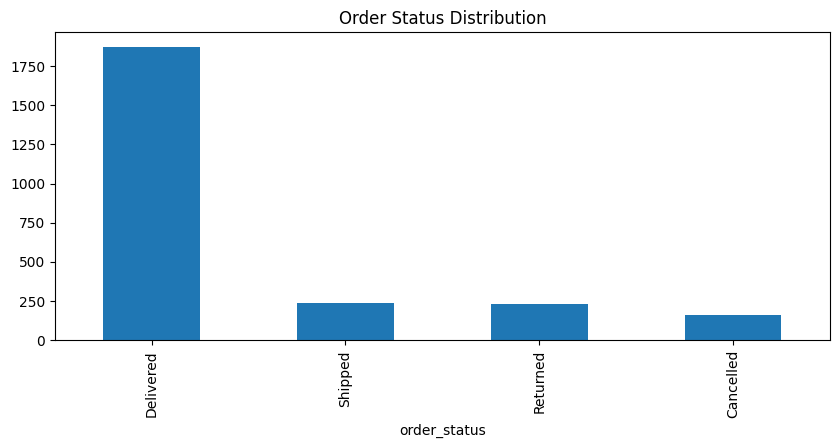

In [23]:
# 6 Visualization

plt.figure(figsize=(10,4))

order_status.plot(kind='bar')

plt.title('Order Status Distribution')

plt.show()

## Step 12: Demographic Segmentation by Age Group
To identify our core customer profiles, individual customer ages are binned into specific cohorts (e.g., Under 25, 25-34, 35-44, 45-54, 55+). Mapping net sales across these groups highlights which age brackets drive the highest transactional value.

In [24]:
# Customer Age Analysis
# 1. Adjust the bins to match the starting points of your SQL CASE statement

bins = [0, 25, 35, 45, 55, 101]                                     # 101 ensures age 100 is caught
labels = ['Under 25', '25-34', '35-44', '45-54', '55+']

df['age_group'] = pd.cut(                                           # 2. Add right=False to make the LEFT side inclusive
    df['customer_age'],
    bins=bins,
    labels=labels,
    right=False                                                     # <-- THIS FIXES THE INCLUSIVITY LOGIC
)

In [25]:
# Revenue by age group:

age_sales = (
    df.groupby('age_group')['net_sales']
      .sum()
      .sort_index()                                                 # <-- Change .sort_values() to .sort_index()
)

age_sales

age_group
Under 25    3718261.59
25-34       7617300.58
35-44       6456065.02
45-54       8235361.64
55+         2953447.62
Name: net_sales, dtype: float64

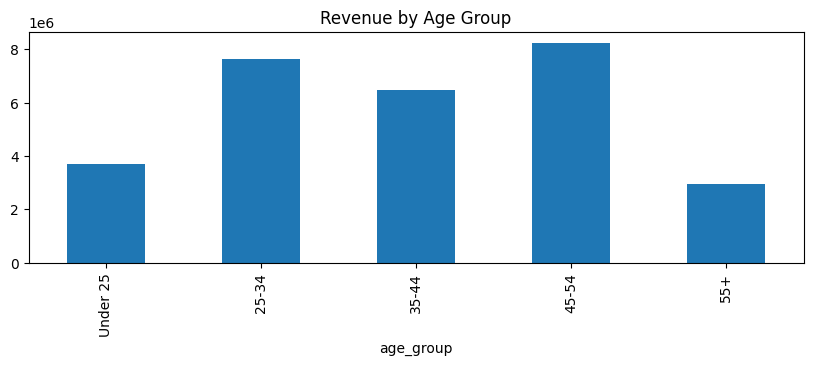

In [26]:
# 7 Visualization

plt.figure(figsize=(10,3))

age_sales.plot(kind='bar')

plt.title('Revenue by Age Group')

plt.show()

## Step 13: Top 10 Products by Net Sales Contribution
Granular product-level analysis helps identify the most popular inventory items. We isolate the top 10 products by overall sales volume to guide promotional focus and marketing efforts.

In [27]:
# Top Products Analysis

top_products = (
    df.groupby('product')['net_sales']
      .sum()
      .sort_values(ascending=False)
)

top_products.head(10)

product
Laptop               7868192.85
Smartphone           4071525.12
LED TV               3895764.75
Tablet               2820933.88
Water Purifier       1570951.64
Smart Watch           993221.40
Air Fryer             929789.27
Bluetooth Speaker     633494.12
Bluetooth Earbuds     624956.21
Cookware Set          518471.88
Name: net_sales, dtype: float64

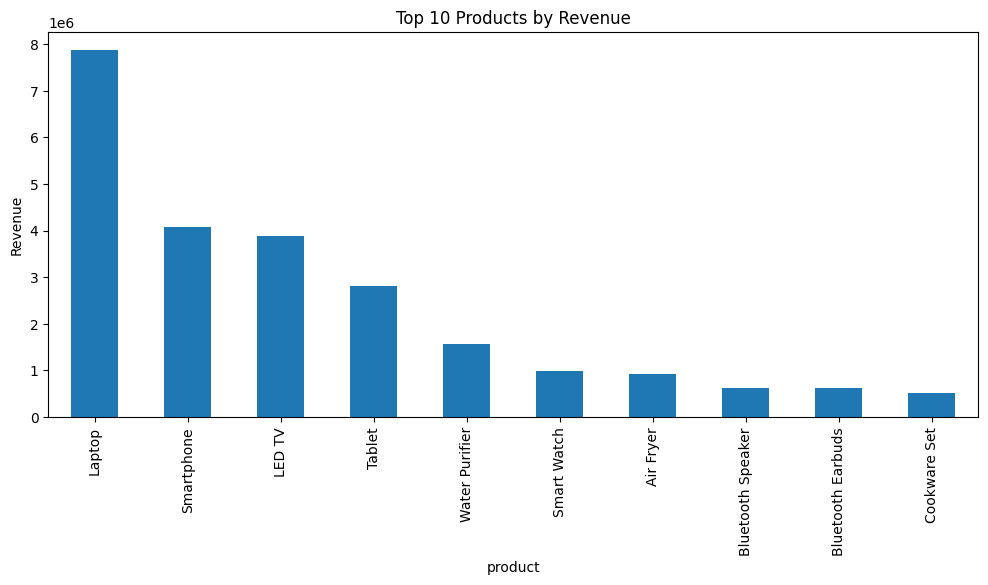

In [28]:
# 8 Visualization

plt.figure(figsize=(12,5))

top_products.head(10).plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.ylabel('Revenue')

plt.show()

## Step 14: Top 10 Products by Absolute Net Profit Dollar Contribution
This section highlights the top 10 products ordered by net profit dollars. Focusing on products like Laptops or Smartphones ensures that sales efforts directly target inventory that drives the highest bottom-line value.

In [29]:
# Top Products by Profit

top_profit_products = (
    df.groupby('product')['profit']
      .sum()
      .sort_values(ascending=False)
)

top_profit_products.head(10)

product
Laptop            1232036.42
Smartphone         677288.47
LED TV             574620.39
Tablet             529934.32
Water Purifier     478485.31
Air Fryer          256090.94
Smart Watch        174904.34
Cookware Set       148850.23
Sneakers           130995.40
Handbag            122691.11
Name: profit, dtype: float64

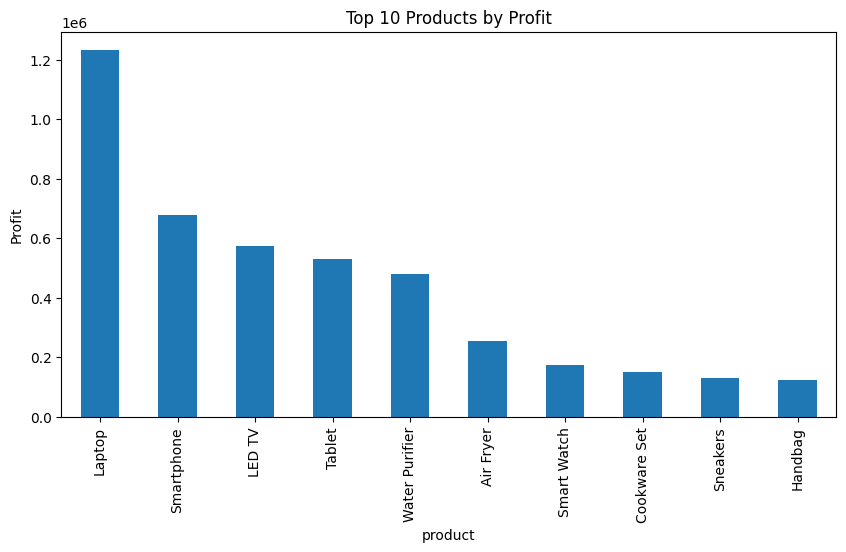

In [30]:
# 9 Visualization

plt.figure(figsize=(10,5))

top_profit_products.head(10).plot(kind='bar')

plt.title('Top 10 Products by Profit')
plt.ylabel('Profit')

plt.show()

## Step 15: Multivariate Correlation Analysis
Using a Pearson correlation matrix and a Seaborn heatmap, we evaluate the relationships between numeric variables such as quantity, unit price, discounts, GST rates, and profits. This helps identify the key factors that influence transaction margins.

In [31]:
# Correlation Analysis

numeric_cols = [
    'quantity',
    'unit_price',
    'gross_sales',
    'discount_amount',
    'net_sales',
    'gst_amount',
    'delivery_days',
    'customer_rating',
    'profit'
]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,quantity,unit_price,gross_sales,discount_amount,net_sales,gst_amount,delivery_days,customer_rating,profit
quantity,1.000000,0.010207,0.227173,0.139669,0.227971,0.222873,-0.032816,0.002327,0.245193
unit_price,0.010207,1.000000,0.842962,0.537490,0.843989,0.819167,0.017499,-0.008083,0.731583
gross_sales,0.227173,0.842962,1.000000,0.677017,0.997251,0.976205,-0.012081,-0.030409,0.854577
discount_amount,0.139669,0.537490,0.677017,1.000000,0.620619,0.610323,-0.011982,-0.022400,0.257751
net_sales,0.227971,0.843989,0.997251,0.620619,1.000000,0.978614,-0.011665,-0.030155,0.884529
gst_amount,0.222873,0.819167,0.976205,0.610323,0.978614,1.000000,-0.015486,-0.032352,0.860923
delivery_days,-0.032816,0.017499,-0.012081,-0.011982,-0.011665,-0.015486,1.000000,0.002398,-0.011512
customer_rating,0.002327,-0.008083,-0.030409,-0.022400,-0.030155,-0.032352,0.002398,1.000000,-0.022027
profit,0.245193,0.731583,0.854577,0.257751,0.884529,0.860923,-0.011512,-0.022027,1.000000


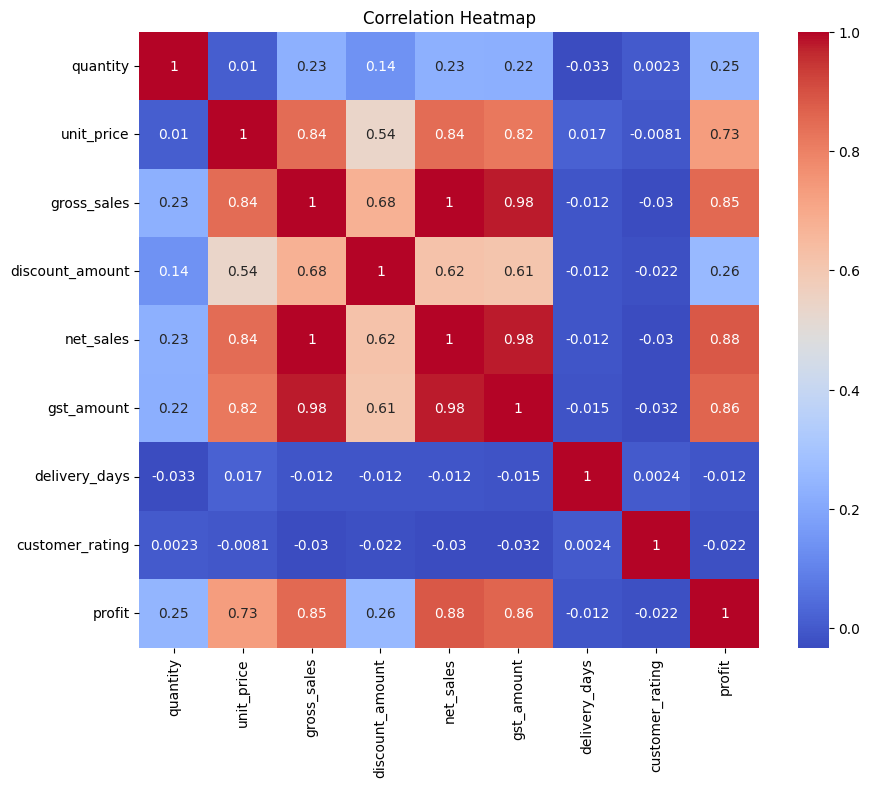

In [32]:
# 10 Visualization
# Why create a heatmap?
    # To identify relationships between variables and understand which factors influence revenue and profit.

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

## Step 16: Customer Spending Profiles & Valuation Distribution
We group transactional data by customer IDs to compute key consumer distribution metrics. Determining the mean, median, and maximum spending tiers helps establish accurate benchmarks for target customer segments.

In [33]:
# Customer Analysis

customer_revenue = (
    df.groupby('customer_id')['net_sales']
      .sum()
)

In [34]:
# This tells us:
# Average customer value
# Median customer value
# Highest customer value

customer_revenue.describe()

count      2465.000000
mean      11756.769351
std       31688.647607
min          71.340000
25%         903.440000
50%        2499.000000
75%        7198.000000
max      449996.400000
Name: net_sales, dtype: float64

## Step 17: Customer Feedback & Satisfaction Distribution
Customer reviews and ratings serve as our primary indicator of product satisfaction. Analyzing the distribution of ratings (averaging a steady \sim 4.02/5) gives a clear view of quality control and customer experience across channels.

In [35]:
# Customer Ratings Analysis
    # missing ratings?

df['customer_rating'].describe()


count    2101.000000
mean        4.015231
std         1.069382
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: customer_rating, dtype: float64

In [36]:
# Average rating:

df['customer_rating'].mean()

np.float64(4.015230842455973)

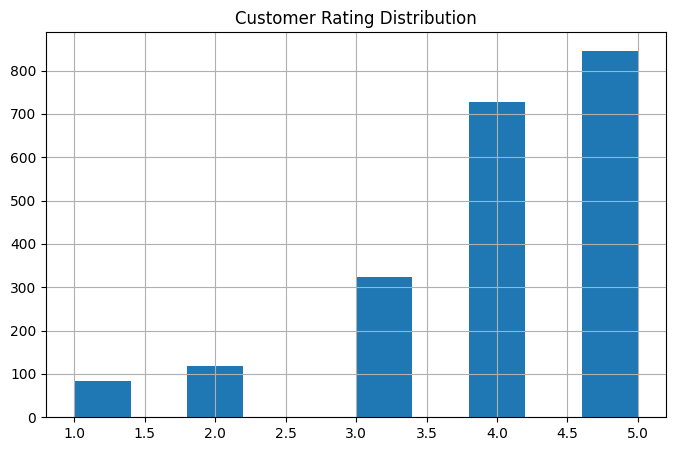

In [37]:
# 11 Visualization

plt.figure(figsize=(8,5))

df['customer_rating'].hist()

plt.title('Customer Rating Distribution')

plt.show()

## Step 18: Processed Data Export
With the engineering, profiling, and descriptive aggregations complete, the processed dataset is saved into a clean format (`ecommerce_clean.csv`). This file is ready for downstream use in live business intelligence applications like Tableau or Power BI.

In [38]:
# Export Clean Dataset

df.to_csv(r"E:\All My Study\Data Analytics Projects\All My Projects Inside\01 data\Project_2_E_Commerce\ecommerce_clean.csv",index=False)